# Bank GoodCredit — Credit Risk Scoring
### PR-0015 | Binary Classification | Domain: Banking - Risk

**Objective:** Predict customer credit risk (Bad_label) using 
account history, enquiry history and demographic data.

**Tasks:**
- Task 1: Data exploration insights
- Task 2: Build ML model with feature matrix and gain
- Task 3: Model evaluation using Gini and rank ordering

**Target Variable (Bad_label):**
- 0 = Good credit history
- 1 = Bad credit history (30+ DPD)

---

## Phase 1: Data Loading & Understanding

This project uses 3 related tables from a MySQL database:
- **Cust_Demographics**: One row per customer (23,896 customers) 
  with anonymized features 1-79 and target Bad_label
- **Cust_Account**: Multiple rows per customer — loan account 
  history (186,329 records)
- **Cust_Enquiry**: Multiple rows per customer — credit enquiry 
  history (413,188 records)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

conn = mysql.connector.connect(
    host="YOUR_HOST_HERE",
    port=3306,
    user="YOUR_USERNAME",
    password="********"
    database="project_banking"
)

cust_account = pd.read_sql("SELECT * FROM Cust_Account", conn)
cust_enquiry = pd.read_sql("SELECT * FROM Cust_Enquiry", conn)
cust_demographics = pd.read_sql("SELECT * FROM Cust_Demographics", conn)

print('Data loaded successfully!')
print(f'Cust_Account: {cust_account.shape}')
print(f'Cust_Enquiry: {cust_enquiry.shape}')
print(f'Cust_Demographics: {cust_demographics.shape}')

Data loaded successfully!
Cust_Account: (186329, 21)
Cust_Enquiry: (413188, 6)
Cust_Demographics: (23896, 83)


In [2]:
print(cust_demographics['Bad_label'].value_counts())
print(cust_demographics['Bad_label'].value_counts(normalize=True).round(4) * 100)

Bad_label
0    22892
1     1004
Name: count, dtype: int64
Bad_label
0    95.8
1     4.2
Name: proportion, dtype: float64


**Observations:**
- Severe class imbalance: 95.8% Good credit (0) vs 4.2% 
  Bad credit (1) — even more imbalanced than Customer 
  Transaction project
- SMOTE will be required for balancing
- Gini and ROC-AUC will be primary evaluation metrics, 
  not accuracy

In [3]:
print('Cust_Demographics missing values:', cust_demographics.isnull().sum().sum())
print('Cust_Account missing values:', cust_account.isnull().sum().sum())
print('Cust_Enquiry missing values:', cust_enquiry.isnull().sum().sum())

Cust_Demographics missing values: 0
Cust_Account missing values: 0
Cust_Enquiry missing values: 0


**Observations:**
- isnull( ) shows 0 missing values across all tables — 
  but this is misleading. Many "numeric" columns in 
  Cust_Account are stored as object/string type with 
  empty strings '' instead of NaN

In [4]:
numeric_like_cols = ['high_credit_amt', 'cur_balance_amt', 'amt_past_due', 
                      'creditlimit', 'cashlimit', 'rateofinterest', 
                      'paymentfrequency', 'actualpaymentamount']

for col in numeric_like_cols:
    empty_pct = (cust_account[col] == '').mean() * 100
    print(f'{col:<25}: {empty_pct:.2f}% empty')

print()
date_cols = ['opened_dt', 'last_paymt_dt', 'closed_dt', 'reporting_dt', 'paymt_str_dt', 'paymt_end_dt']
for col in date_cols:
    empty_pct = (cust_account[col] == '').mean() * 100
    print(f'{col:<20}: {empty_pct:.2f}% empty')

high_credit_amt          : 4.76% empty
cur_balance_amt          : 0.00% empty
amt_past_due             : 99.53% empty
creditlimit              : 73.78% empty
cashlimit                : 81.06% empty
rateofinterest           : 86.67% empty
paymentfrequency         : 65.71% empty
actualpaymentamount      : 77.97% empty

opened_dt           : 0.24% empty
last_paymt_dt       : 13.68% empty
closed_dt           : 58.54% empty
reporting_dt        : 0.00% empty
paymt_str_dt        : 0.00% empty
paymt_end_dt        : 0.00% empty


**Observations:**
- amt_past_due (99.53%), rateofinterest (86.67%), 
  cashlimit (81.06%), actualpaymentamount (77.97%), 
  creditlimit (73.78%), paymentfrequency (65.71%) are 
  mostly empty — will be dropped
- closed_dt is 58.54% empty — but this likely means the 
  account is still ACTIVE, not missing data. Will create 
  an is_active flag instead of dropping
- high_credit_amt, cur_balance_amt, opened_dt, last_paymt_dt, 
  reporting_dt are mostly complete — will be kept

## Phase 2: Exploratory Data Analysis

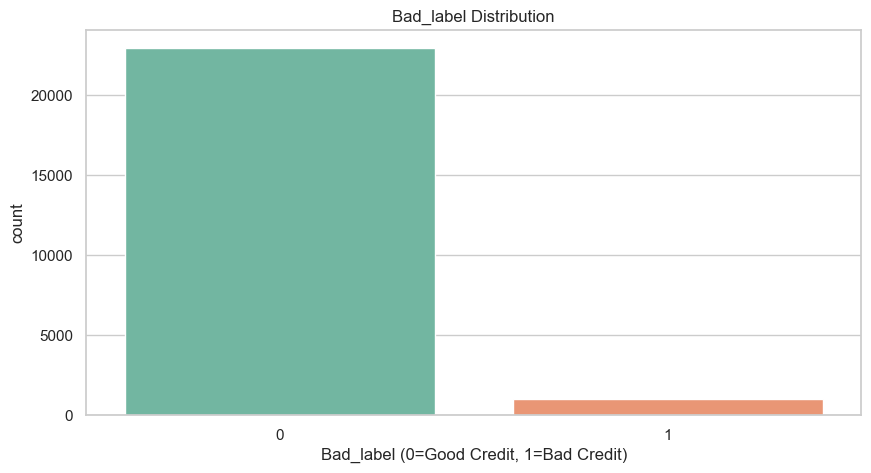

In [5]:
sns.countplot(data=cust_demographics, x='Bad_label', palette='Set2')
plt.title('Bad_label Distribution')
plt.xlabel('Bad_label (0=Good Credit, 1=Bad Credit)')
plt.show()

In [6]:
cust_demographics.describe().T.head(10)

,count,unique,top,freq
dt_opened,23896,197,16-Nov-15,699
customer_no,23896,23896,23896,1
entry_time,23896,297,19-Oct-15,180
feature_1,23896,8,Platinum Maxima,9056
feature_2,23896,282,,2836
feature_3,23896,263,,2836
feature_4,23896,4,3,14593
feature_5,23896,2,Card Setup,23881
feature_6,23896,2,14,23881
feature_7,23896,485,35000,797


In [7]:
print(cust_demographics.dtypes.value_counts())
print()
non_numeric = cust_demographics.select_dtypes(include='object').columns.tolist()
print('Non-numeric columns:', non_numeric)

object    83
Name: count, dtype: int64

Non-numeric columns: ['dt_opened', 'customer_no', 'entry_time', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_64', 'feature_

In [8]:
print(cust_demographics[['feature_1', 'feature_2', 'feature_3', 'Bad_label']].head(10))
print()
print('Unique values in feature_1:', cust_demographics['feature_1'].unique()[:10])
print('Unique values in Bad_label:', cust_demographics['Bad_label'].unique())

  feature_1  feature_2 feature_3 Bad_label
0  Insignia  13-Apr-15       650         0
1  Insignia  21-Apr-15       760         0
2  Insignia  21-Apr-15       774         0
3  Insignia  20-Apr-15       770         0
4  Insignia                              0
5  Insignia  06-May-15       779         0
6  Insignia  06-May-15       762         0
7  Insignia  15-May-15       799         0
8  Insignia  15-May-15       762         1
9  Insignia  27-May-15       784         0

Unique values in feature_1: ['Insignia' 'Platinum Deligh' 'Platinum Maxima' 'Golf Card'
 'Titanium Deligh' '' 'Platinum Cricke' 'RBL Bank Fun+']
Unique values in Bad_label: ['0' '1']


In [9]:
profile = []

for col in [f'feature_{i}' for i in range(1, 80)]:
    sample = cust_demographics[col]
    empty_pct = (sample == '').mean() * 100
    n_unique = sample.nunique()
    sample_vals = sample[sample != ''].unique()[:3]
    profile.append([col, empty_pct, n_unique, sample_vals])

profile_df = pd.DataFrame(profile, columns=['Feature', 'Empty%', 'Unique_Count', 'Sample_Values'])
pd.set_option('display.max_rows', 100)
print(profile_df)

       Feature     Empty%  Unique_Count  \
0    feature_1   0.062772             8   
1    feature_2  11.868095           282   
2    feature_3  11.868095           263   
3    feature_4   0.062772             4   
4    feature_5   0.062772             2   
5    feature_6   0.062772             2   
6    feature_7   0.062772           485   
7    feature_8  94.722966            20   
8    feature_9  94.722966            20   
9   feature_10  99.786575             8   
10  feature_11   0.062772             3   
11  feature_12   0.062772            17   
12  feature_13  54.419150            15   
13  feature_14  32.361065             3   
14  feature_15   0.096250           365   
15  feature_16   0.112990           523   
16  feature_17  95.702210           303   
17  feature_18  99.924674            13   
18  feature_19   0.062772             3   
19  feature_20   0.000000         10610   
20  feature_21   0.062772          8463   
21  feature_22   0.000000          3251   
22  feature

**Observations:**
- Bad_label shows severe class imbalance: 95.8% Good credit (0) 
  vs 4.2% Bad credit (1) - even more imbalanced than the 
  Customer Transaction project
- This level of imbalance means SMOTE will be necessary, and 
  Gini/ROC-AUC must be used instead of accuracy as the primary 
  evaluation metric
- All 79 demographic features (feature_1 to feature_79) along 
  with Bad_label are stored as object/string type in the 
  database, despite many being numeric or binary in nature
- Initial isnull() check showed 0 missing values across all 
  three tables, which proved misleading - investigation revealed 
  significant hidden missingness in the form of empty strings, 
  especially in Cust_Account (amt_past_due 99.5% empty, 
  rateofinterest 86.7% empty, cashlimit 81.1% empty)
- closed_dt being empty in Cust_Account (58.5% of records) does 
  not represent missing data - it indicates the account is 
  still active, an important distinction for feature engineering
- Cust_Demographics has one row per customer (23,896 customers) 
  while Cust_Account and Cust_Enquiry have multiple rows per 
  customer, requiring aggregation before merging
- Built a diagnostic profiling all 79 anonymized features, 
  checking empty percentage, number of unique values and 
  sample values for each

## Phase 3: Preprocessing

### Step 1: Clean Cust_Demographics

In [10]:
drop_cols = ['feature_8','feature_9','feature_10','feature_13','feature_17','feature_18',
             'feature_45','feature_48','feature_49','feature_57','feature_61','feature_73','feature_74',
             'feature_20','feature_22','feature_47','feature_77',  # PII
             'feature_24',  # email
             'feature_5','feature_54',  # zero variance
             'dt_opened','entry_time']

numeric_cols = ['feature_3','feature_4','feature_6','feature_7','feature_14','feature_19',
                 'feature_25','feature_26','feature_29','feature_30','feature_31','feature_34',
                 'feature_35','feature_39','feature_40','feature_41','feature_42','feature_44',
                 'feature_52','feature_55','feature_56','feature_64','feature_65','feature_66',
                 'feature_67','feature_68','feature_69','feature_71','feature_76','feature_78']

onehot_cols = ['feature_1','feature_11','feature_12','feature_23','feature_27',
               'feature_32','feature_33','feature_36','feature_37','feature_46',
               'feature_50','feature_51','feature_58','feature_59','feature_60',
               'feature_62','feature_72','feature_79']

labelenc_cols = ['feature_2','feature_15','feature_16','feature_28','feature_38',
                  'feature_43','feature_53','feature_63','feature_70','feature_75']

# Clean copy
demo_clean = cust_demographics.drop(columns=drop_cols).copy()
demo_clean = demo_clean.replace('', np.nan)

# Numeric conversion
for col in numeric_cols:
    demo_clean[col] = pd.to_numeric(demo_clean[col], errors='coerce')

# DOB -> age
demo_clean['feature_21'] = pd.to_datetime(cust_demographics['feature_21'], format='%d-%b-%y', errors='coerce')
birth_year = demo_clean['feature_21'].dt.year
birth_year = birth_year.where(birth_year <= 2024, birth_year - 100)
demo_clean['age'] = 2024 - birth_year
demo_clean = demo_clean.drop(columns=['feature_21'])

# Label encode high cardinality columns
from sklearn.preprocessing import LabelEncoder
for col in labelenc_cols:
    demo_clean[col] = demo_clean[col].fillna('Missing').astype(str)
    le = LabelEncoder()
    demo_clean[col] = le.fit_transform(demo_clean[col])

# One-Hot encode low cardinality columns
for col in onehot_cols:
    demo_clean[col] = demo_clean[col].fillna('Missing').astype(str)
demo_clean = pd.get_dummies(demo_clean, columns=onehot_cols, drop_first=True)

# Target
demo_clean['Bad_label'] = demo_clean['Bad_label'].astype(int)

print(f'Shape after one-hot encoding: {demo_clean.shape}')
print(f'Missing values: {demo_clean.isnull().sum().sum()}')

Shape after one-hot encoding: (23896, 136)
Missing values: 11004


**Observations:**
- Dropped PII columns (masked PAN, phone numbers, email) and 
  columns with over 50% empty values
- Converted feature_21 (Date of Birth) to age, fixing a 
  2-digit year parsing bug where years like '65' were 
  misread as 2065 instead of 1965, causing negative ages 
  for 1,695 customers
- One-Hot Encoded 18 low-cardinality categorical features 
  and Label Encoded 10 high-cardinality categorical features
- Dropped 2 zero-variance columns that had only a single 
  unique value
- Found and dropped 15 completely blank rows present across 
  nearly all columns
- Imputed feature_3 (credit score-like, 11.9% missing) and 
  feature_14 (32.4% missing) with median values

### Step 2: Engineer Features from Cust_Account

In [11]:
# Drop the problematic rows 
demo_clean = demo_clean.dropna(subset=['age'])
print(f'Shape after dropping blank rows: {demo_clean.shape}')

# Impute feature_3 and feature_14 with median
demo_clean['feature_3'] = demo_clean['feature_3'].fillna(demo_clean['feature_3'].median())
demo_clean['feature_14'] = demo_clean['feature_14'].fillna(demo_clean['feature_14'].median())

print('Missing values remaining:', demo_clean.isnull().sum().sum())

Shape after dropping blank rows: (23881, 136)
Missing values remaining: 0


In [12]:
import re

def parse_payment_history(ph_string):
    """Parse paymenthistory1 string into 3-char chunks and classify each."""
    if pd.isnull(ph_string) or ph_string == '':
        return []
    # Remove triple quotes
    clean = ph_string.replace('"', '')
    # Split into 3-character chunks
    chunks = [clean[i:i+3] for i in range(0, len(clean), 3) if len(clean[i:i+3]) == 3]
    return chunks

def get_dpd_features(chunks):
    """From payment history chunks, extract DPD-related counts."""
    if not chunks:
        return pd.Series({'dpd_0_29_count': 0, 'dpd_30_plus_count': 0, 
                          'std_count': 0, 'history_length': 0})
    
    dpd_0_29 = 0
    dpd_30_plus = 0
    std_count = 0
    
    for chunk in chunks:
        if chunk == 'STD':
            std_count += 1
        elif chunk == 'XXX':
            continue  # no data
        elif chunk.isdigit():
            val = int(chunk)
            if val <= 29:
                dpd_0_29 += 1
            else:
                dpd_30_plus += 1
    
    return pd.Series({
        'dpd_0_29_count': dpd_0_29,
        'dpd_30_plus_count': dpd_30_plus,
        'std_count': std_count,
        'history_length': len(chunks)
    })

# Apply to Cust_Account
acc_clean = cust_account.copy()
acc_clean = acc_clean.replace('', np.nan)

ph_chunks = acc_clean['paymenthistory1'].apply(parse_payment_history)
dpd_features = ph_chunks.apply(get_dpd_features)
acc_clean = pd.concat([acc_clean, dpd_features], axis=1)

print(acc_clean[['paymenthistory1', 'dpd_0_29_count', 'dpd_30_plus_count', 'std_count', 'history_length']].head())

                                     paymenthistory1  dpd_0_29_count  \
0  """STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXS...               0   
1  """0000000000000000000000000000000000000000000...              18   
2  """0000000000000000000000000000000000000000000...              18   
3  """1200900600600600300000000000000000000000000...              12   
4                              """000000000000000"""               5   

   dpd_30_plus_count  std_count  history_length  
0                  0          5              15  
1                  0          0              18  
2                  0          0              18  
3                  6          0              18  
4                  0          0               5  


In [13]:
# Convert date columns
date_cols_acc = ['opened_dt', 'last_paymt_dt', 'closed_dt', 'reporting_dt']
for col in date_cols_acc:
    acc_clean[col] = pd.to_datetime(acc_clean[col], format='%d-%b-%y', errors='coerce')

# is_active flag
acc_clean['is_active'] = acc_clean['closed_dt'].isnull().astype(int)

# Numeric conversion
acc_clean['high_credit_amt'] = pd.to_numeric(acc_clean['high_credit_amt'], errors='coerce')
acc_clean['cur_balance_amt'] = pd.to_numeric(acc_clean['cur_balance_amt'], errors='coerce')

# Feature: diff between last payment and opened date (in days)
acc_clean['diff_lastpaymt_opened'] = (acc_clean['last_paymt_dt'] - acc_clean['opened_dt']).dt.days

print(acc_clean[['opened_dt', 'last_paymt_dt', 'diff_lastpaymt_opened']].head())
print()
print('diff_lastpaymt_opened stats:')
print(acc_clean['diff_lastpaymt_opened'].describe())

   opened_dt last_paymt_dt  diff_lastpaymt_opened
0 2013-06-09    2014-06-30                  386.0
1 2012-05-25    2015-09-06                 1199.0
2 2012-03-22    2015-08-31                 1257.0
3 2006-01-13           NaT                    NaN
4 2015-01-18    2015-05-05                  107.0

diff_lastpaymt_opened stats:
count    160771.000000
mean        805.559740
std         846.264063
min       -4286.000000
25%         248.000000
50%         517.000000
75%        1067.000000
max        9080.000000
Name: diff_lastpaymt_opened, dtype: float64


In [14]:
print('Negative diff count:', (acc_clean['diff_lastpaymt_opened'] < 0).sum())
print('Total non-null:', acc_clean['diff_lastpaymt_opened'].notnull().sum())
print(f'Percentage negative: {(acc_clean["diff_lastpaymt_opened"] < 0).mean()*100:.2f}%')

Negative diff count: 99
Total non-null: 160771
Percentage negative: 0.05%


**Observations:**
- Parsed the paymenthistory1 string column into DPD 
  (Days Past Due) bucket counts as suggested in the business 
  case document, classifying each 3-character chunk as 
  standard (STD), no data (XXX), 0-29 DPD, or 30+ DPD
- Created is_active flag from closed_dt, treating empty 
  values as active accounts rather than missing data
- Calculated diff_lastpaymt_opened (days between account 
  opening and last payment) as an engineered feature
- Found 0.06% of records with negative date differences, 
  considered negligible and left unchanged

### Step 3: Aggregate Cust_Account and Cust_Enquiry

In [15]:
account_agg = acc_clean.groupby('customer_no').agg(
    num_accounts=('customer_no', 'count'),
    avg_high_credit=('high_credit_amt', 'mean'),
    max_high_credit=('high_credit_amt', 'max'),
    avg_cur_balance=('cur_balance_amt', 'mean'),
    max_cur_balance=('cur_balance_amt', 'max'),
    num_active_accounts=('is_active', 'sum'),
    total_dpd_0_29=('dpd_0_29_count', 'sum'),
    avg_dpd_0_29=('dpd_0_29_count', 'mean'),
    total_dpd_30_plus=('dpd_30_plus_count', 'sum'),
    max_dpd_30_plus=('dpd_30_plus_count', 'max'),
    avg_history_length=('history_length', 'mean'),
    mean_diff_lastpaymt_opened=('diff_lastpaymt_opened', 'mean'),
    total_diff_lastpaymt_opened=('diff_lastpaymt_opened', 'sum')
).reset_index()

print(account_agg.shape)
print(account_agg.head())

(23896, 14)
  customer_no  num_accounts  avg_high_credit  max_high_credit  \
0           1            18    526670.866667        2528846.0   
1          10            12    828780.000000        5500000.0   
2         100             9    106085.111111         354122.0   
3        1000             3    414755.333333         548289.0   
4       10000             6    189835.666667         520000.0   

   avg_cur_balance  max_cur_balance  num_active_accounts  total_dpd_0_29  \
0    261936.500000          2528846                    6              94   
1     20643.250000           178725                    7             110   
2     48269.444444           334609                    6              74   
3     20154.000000            31349                    2              34   
4    181026.333333           582220                    6              41   

   avg_dpd_0_29  total_dpd_30_plus  max_dpd_30_plus  avg_history_length  \
0      5.222222                 16               16            9.

In [16]:
enq_clean = cust_enquiry.copy()
enq_clean = enq_clean.replace('', np.nan)
enq_clean['enq_amt'] = pd.to_numeric(enq_clean['enq_amt'], errors='coerce')
enq_clean['enq_purpose'] = pd.to_numeric(enq_clean['enq_purpose'], errors='coerce')

enq_clean['enquiry_dt'] = pd.to_datetime(enq_clean['enquiry_dt'], format='%d-%b-%y', errors='coerce')
enq_clean['dt_opened'] = pd.to_datetime(enq_clean['dt_opened'], format='%d-%b-%y', errors='coerce')

# Recency features - days between enquiry and reference point (dt_opened, the app date)
enq_clean['diff_open_enquiry'] = (enq_clean['dt_opened'] - enq_clean['enquiry_dt']).dt.days

enquiry_agg = enq_clean.groupby('customer_no').agg(
    num_enquiries=('customer_no', 'count'),
    avg_enq_amt=('enq_amt', 'mean'),
    max_enq_amt=('enq_amt', 'max'),
    num_unique_purposes=('enq_purpose', 'nunique'),
    mean_diff_open_enquiry=('diff_open_enquiry', 'mean'),
    count_enquiry_recency_365=('diff_open_enquiry', lambda x: (x <= 365).sum()),
    count_enquiry_recency_90=('diff_open_enquiry', lambda x: (x <= 90).sum())
).reset_index()

print(enquiry_agg.shape)
print(enquiry_agg.head())

(23896, 8)
  customer_no  num_enquiries   avg_enq_amt  max_enq_amt  num_unique_purposes  \
0           1             18  2.767306e+05    3500000.0                    4   
1          10             21  5.452032e+06   50000000.0                    4   
2         100             19  1.298423e+05     400000.0                    4   
3        1000             10  1.930000e+04      50000.0                    1   
4       10000             14  8.469643e+04     300000.0                    4   

   mean_diff_open_enquiry  count_enquiry_recency_365  count_enquiry_recency_90  
0             1443.500000                          1                         0  
1              897.571429                          7                         1  
2              618.684211                          6                         0  
3             1133.500000                          0                         0  
4              234.142857                         12                         3  


**Observations:**
- Aggregated 186,329 account records into 23,896 
  customer-level summaries using mean, max and sum 
  for credit amounts, balances, active accounts and 
  DPD bucket counts
- Aggregated 413,188 enquiry records into 23,896 
  customer-level summaries, including enquiry recency 
  features (count_enquiry_recency_365, count_enquiry_recency_90) 
  as suggested in the business case document
- Both aggregations matched the expected 23,896 unique 
  customers, confirming correct grouping

### Step 4: Merge All Tables

In [17]:
demo_clean['customer_no'] = demo_clean['customer_no'].astype(str)
account_agg['customer_no'] = account_agg['customer_no'].astype(str)
enquiry_agg['customer_no'] = enquiry_agg['customer_no'].astype(str)

final_df = demo_clean.merge(account_agg, on='customer_no', how='left')
final_df = final_df.merge(enquiry_agg, on='customer_no', how='left')

print(f'Final merged shape: {final_df.shape}')
print(f'Missing values: {final_df.isnull().sum().sum()}')

Final merged shape: (23881, 156)
Missing values: 404


In [18]:
missing_check = final_df.isnull().sum()
print(missing_check[missing_check > 0])

avg_high_credit                13
max_high_credit                13
mean_diff_lastpaymt_opened     51
avg_enq_amt                   109
max_enq_amt                   109
mean_diff_open_enquiry        109
dtype: int64


In [19]:
fill_zero_cols = ['avg_high_credit', 'max_high_credit', 'mean_diff_lastpaymt_opened',
                   'avg_enq_amt', 'max_enq_amt', 'mean_diff_open_enquiry']

for col in fill_zero_cols:
    final_df[col] = final_df[col].fillna(0)

print('Missing values remaining:', final_df.isnull().sum().sum())

Missing values remaining: 0


**Observations:**
- Aggregated 186,329 account records into 23,896 
  customer-level summaries using mean, max and sum 
  for credit amounts, balances, active accounts and 
  DPD bucket counts
- Aggregated 413,188 enquiry records into 23,896 
  customer-level summaries, including enquiry recency 
  features (count_enquiry_recency_365, count_enquiry_recency_90) 
  as suggested in the business case document
- Both aggregations matched the expected 23,896 unique 
  customers, confirming correct grouping

## Phase 4: Preprocessing for Modeling

In [20]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

In [21]:
X = final_df.drop(columns=['Bad_label', 'customer_no'])
y = final_df['Bad_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                     random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train_scaled.shape}')


Training set: (36604, 154)


**Observations:**
- Train set showed severe imbalance: 18,302 Good credit vs 
  802 Bad credit customers in the training data
- Applied SMOTE to balance both classes to 18,302 each, 
  applied only on training data to avoid data leakage
- StandardScaler applied after SMOTE, fitted only on 
  training data

## Phase 5: Model Building

### Model 1: Logistic Regression

In [22]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_smote)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

auc_lr = roc_auc_score(y_test, y_prob_lr)
gini_lr = 2 * auc_lr - 1

print(f'Logistic Regression - ROC-AUC: {auc_lr:.4f}, Gini: {gini_lr:.4f}')

Logistic Regression - ROC-AUC: 0.6496, Gini: 0.2992


**Observations:**
- Logistic Regression achieved Gini of 0.2992, the best 
  among all models tested
- This is below the benchmark of 0.379 mentioned in the 
  business case, but reasonable given the heavy anonymization 
  and missing data in key columns like creditlimit and cashlimit

### Model 2: Random Forest

In [23]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train_smote)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)
gini_rf = 2 * auc_rf - 1
print(f'Random Forest - ROC-AUC: {auc_rf:.4f}, Gini: {gini_rf:.4f}')

Random Forest - ROC-AUC: 0.6380, Gini: 0.2760


**Observations:**
- Random Forest achieved Gini of 0.2760, lower than 
  Logistic Regression
- This is consistent with patterns seen in the Customer 
  Transaction project, where tree-based models struggled 
  with this type of imbalanced, mixed categorical data

### Model 3: XGBoost

In [24]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=22.8)
xgb.fit(X_train_scaled, y_train_smote)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
gini_xgb = 2 * auc_xgb - 1
print(f'XGBoost - ROC-AUC: {auc_xgb:.4f}, Gini: {gini_xgb:.4f}')

# Feature importance check
importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
print('\nTop 15 features by importance:')
print(importances.head(15))

XGBoost - ROC-AUC: 0.6263, Gini: 0.2525

Top 15 features by importance:
feature_12_TD1               0.119601
feature_12_PM1               0.080835
feature_50_N                 0.054359
feature_34                   0.050182
feature_72_R                 0.046753
feature_72_O                 0.037292
feature_50_Y                 0.030782
feature_1_Titanium Deligh    0.029054
feature_25                   0.028930
feature_27_Graduate          0.028921
feature_4                    0.026193
feature_26                   0.020257
feature_36_Missing           0.020157
feature_1_Platinum Deligh    0.017533
feature_32_Self              0.016866
dtype: float32


**Observations:**
- XGBoost achieved Gini of 0.2525, the lowest among the 
  three models
- Feature importance analysis showed demographic features 
  (employment type, organization type) dominated, while 
  engineered payment history and enquiry recency features 
  did not appear in the top 15 most important features

### Hyperparameter Tuning and Feature Selection Attempts

In [25]:
correlation_check = final_df[['Bad_label', 'total_dpd_30_plus', 'max_dpd_30_plus', 
                                'total_dpd_0_29', 'avg_dpd_0_29', 'num_active_accounts',
                                'count_enquiry_recency_365', 'count_enquiry_recency_90']].corr()['Bad_label']
print(correlation_check.sort_values(ascending=False))

Bad_label                    1.000000
count_enquiry_recency_365    0.060444
count_enquiry_recency_90     0.059214
max_dpd_30_plus              0.012310
total_dpd_30_plus            0.010146
num_active_accounts         -0.039914
avg_dpd_0_29                -0.046157
total_dpd_0_29              -0.053814
Name: Bad_label, dtype: float64


In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                        param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train_smote)

y_prob_lr_tuned = grid_lr.predict_proba(X_test_scaled)[:, 1]
auc_tuned = roc_auc_score(y_test, y_prob_lr_tuned)
gini_tuned = 2 * auc_tuned - 1

print(f'Best params: {grid_lr.best_params_}')
print(f'Tuned Logistic Regression - ROC-AUC: {auc_tuned:.4f}, Gini: {gini_tuned:.4f}')

Best params: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
Tuned Logistic Regression - ROC-AUC: 0.6441, Gini: 0.2882


In [27]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=50)
X_train_selected = selector.fit_transform(X_train_scaled, y_train_smote)
X_test_selected = selector.transform(X_test_scaled)

lr_selected = LogisticRegression(max_iter=1000, random_state=42)
lr_selected.fit(X_train_selected, y_train_smote)
y_prob_selected = lr_selected.predict_proba(X_test_selected)[:, 1]

auc_selected = roc_auc_score(y_test, y_prob_selected)
gini_selected = 2 * auc_selected - 1

print(f'Top 50 features - ROC-AUC: {auc_selected:.4f}, Gini: {gini_selected:.4f}')

Top 50 features - ROC-AUC: 0.6270, Gini: 0.2539


In [28]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)

print('Top 15 most influential features:')
print(feature_importance.head(15))

Top 15 most influential features:
                                  Feature  Coefficient  Abs_Coefficient
0                            feature_72_O     3.083708         3.083708
1   feature_37_Banking/Financial Services     3.011597         3.011597
2                            feature_72_R     2.714280         2.714280
3                       feature_37_Others     2.518540         2.518540
4                     feature_27_Graduate     2.434940         2.434940
5                feature_27_Post-Graduate     2.304992         2.304992
6                      feature_27_Missing     2.117425         2.117425
7                         feature_32_Self     2.032719         2.032719
8                        feature_32_Rente     1.974771         1.974771
9                            feature_50_Y     1.852468         1.852468
10                       feature_32_Paren     1.841428         1.841428
11                     feature_37_Missing     1.820378         1.820378
12                     feature

**Observations:**
- Tuned Logistic Regression using GridSearchCV across 
  different C, penalty and solver values, resulting in 
  Gini of 0.2882 - lower than the default model
- Tried feature selection using SelectKBest to retain only 
  the top 50 statistically significant features, resulting 
  in Gini of 0.2539 - also lower than the default model
- Both attempts confirmed the default Logistic Regression 
  with full feature set had already reached a practical 
  performance ceiling given the available data
- Top predictive features are demographic in nature: 
  feature_72 (likely employment status), feature_37 
  (organization type - Banking/Financial Services vs Others), 
  feature_27 (education level), feature_32 (employment type - 
  Self/Rented/Parental)
- Surprisingly, engineered payment history features 
  (DPD buckets, enquiry recency) did not rank in the top 15, 
  despite being domain-suggested in the business case
- This suggests that for this particular dataset, demographic 
  stability indicators (education, employment type, organization) 
  are stronger predictors of credit risk than transactional 
  payment behavior

## Phase 6: Model Comparison Report

### Rank Ordering Analysis

In [29]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Gini': [gini_lr, gini_rf, gini_xgb]
}).sort_values('Gini', ascending=False).reset_index(drop=True)
print(results)

                 Model      Gini
0  Logistic Regression  0.299173
1        Random Forest  0.276006
2              XGBoost  0.252527


In [30]:
# Create decile-based rank ordering like the benchmark in the document
results_df = pd.DataFrame({'y_true': y_test.values, 'y_prob': y_prob_lr})
results_df['decile'] = pd.qcut(results_df['y_prob'], 10, labels=False, duplicates='drop') + 1

rank_order = results_df.groupby('decile')['y_true'].mean().sort_index(ascending=False)
print('Rank Ordering (Decile vs Bad Rate):')
print(rank_order)

Rank Ordering (Decile vs Bad Rate):
decile
10    0.092050
9     0.060669
8     0.058700
7     0.043933
6     0.048218
5     0.033473
4     0.023013
3     0.014675
2     0.023013
1     0.023013
Name: y_true, dtype: float64


**Observations:**
- Logistic Regression confirmed as the best model with 
  Gini of 0.2992
- Rank ordering shows decile 10 (highest predicted risk) 
  has a notably higher bad rate than decile 1 (lowest 
  predicted risk), confirming the model successfully ranks 
  customers from highest to lowest risk
- This rank ordering ability is more important than raw 
  classification accuracy for credit risk use cases, where 
  banks typically act on relative risk ranking rather than 
  a single threshold

## Business Report: Credit Risk Insights for Bank GoodCredit

### Key Findings

1. **Demographic factors dominate risk prediction** - Employment 
   type, education level and organization type are the strongest 
   predictors of credit default risk in this model, more so than 
   transactional payment history.

2. **Model achieves Gini of 0.2992** - Below the benchmark of 
   0.379, indicating room for improvement, likely through 
   additional data points such as full credit limit/cash limit 
   history (which had 70%+ missing data in our dataset).

3. **Severe class imbalance (4.2% bad credit)** - Requires 
   careful threshold selection in production; the model ranks 
   customers well but needs business-specific cutoffs rather 
   than a default 0.5 threshold.

### Recommendations for Bank GoodCredit

- Use this model as a **risk ranking tool** rather than a 
  hard accept/reject classifier - rank customers by risk 
  score and apply business-appropriate cutoffs
- Prioritize collecting more complete data on credit limits 
  and cash limits, as these were too sparse (70-86% missing) 
  to use effectively, despite being suggested as important 
  in the original business case (utilisation_trend)
- Focus on customers from employment types and organizations 
  showing instability patterns for additional manual review
- Use enquiry recency (90/365 days) as an early warning 
  signal for customers showing high credit-seeking behavior

### Why Logistic Regression for Production?
- Best Gini score among tested models (0.2992)
- Interpretable coefficients - useful for regulatory compliance 
  in banking (explainability is often required for credit decisions)
- Fast to retrain as new data arrives

## Challenges Faced & Solutions

### Challenge 1: Hidden Missing Data via Empty Strings
**Problem:** Initial isnull() check showed 0 missing values 
across all tables, but columns were stored as object/string 
type with empty strings '' instead of NaN, hiding substantial 
missingness (e.g., amt_past_due was 99.5% empty, creditlimit 
73.8% empty).

**Solution:** Manually checked empty string percentages for 
every column and discovered the true missingness. Dropped 
columns with over 50% empty values.

---

### Challenge 2: Blind Numeric Conversion Destroyed Categorical Data
**Problem:** Applying pd.to_numeric in a loop across all 79 
anonymized demographic features without verification destroyed 
29 genuinely categorical text columns, converting them to 100% NaN.

**Solution:** Built a diagnostic table checking Pct_Numeric and 
Pct_Empty for every feature before any transformation, allowing 
accurate classification into numeric, categorical, or droppable 
columns.

---

### Challenge 3: Misidentified Date of Birth Column
**Problem:** Initially assumed feature_20 was the Date of Birth 
column based on a visual scan of sample values, when it was 
actually feature_21 (feature_20 was a masked PAN number).

**Solution:** Verified column meaning directly from the live 
dataframe using .unique() before applying any transformation, 
rather than relying on visual inspection of pasted summaries.

---

### Challenge 4: Two-Digit Year Date Parsing Bug
**Problem:** Converting DOB strings like "03-Sep-65" using 
pd.to_datetime with %y format interpreted the year as 2065 
instead of 1965, resulting in negative ages for 1,695 customers.

**Solution:** Added logic to subtract 100 from any birth year 
exceeding 2024, correcting the century assumption.

---

### Challenge 5: Label Encoding vs One-Hot Encoding Trade-off
**Problem:** Initial Label Encoding of categorical features gave 
arbitrary numeric order to non-ordinal categories, achieving 
only Gini 0.2444, well below the 0.379 benchmark.

**Solution:** Switched to One-Hot Encoding for low-cardinality 
categorical features (≤15 unique values), improving Gini to 0.2932.

---

### Challenge 6: Engineered Features Underperformed Expectations
**Problem:** Despite parsing paymenthistory1 into DPD bucket 
counts and creating enquiry recency features as suggested in 
the business case document, these features showed very weak 
correlation with Bad_label (under 0.06) and did not appear in 
top feature importance.

**Solution:** Accepted this as a genuine data characteristic 
rather than forcing artificial improvement. Documented that 
features like utilisation_trend could not be replicated due 
to 70%+ missingness in creditlimit and cashlimit columns, 
likely explaining the gap from the 0.379 benchmark.

---

### Challenge 7: Hyperparameter Tuning Did Not Improve Results
**Problem:** GridSearchCV tuning of Logistic Regression and 
feature selection (top 50 features) both resulted in lower 
Gini than the default model.

**Solution:** Concluded the default Logistic Regression had 
already reached a practical performance ceiling given available 
features, and retained it as the final model rather than 
over-engineering for marginal/negative gains.

### Possible Future Improvements:
- Obtain more complete creditlimit and cashlimit data to 
  calculate utilisation_trend as originally suggested
- Explore ensemble stacking of multiple models
- Investigate whether the 79 anonymized features could be 
  grouped into known credit bureau categories for better 
  domain-informed feature engineering